# Problem 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
def f(x):
    # integrand
    return np.sin(np.sqrt(100*x))**2


def Trapez(f, N, a, b):
    # Trapezoid method
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-1] + y[1:]
    I = np.sum(A)*h*0.5

    return I


def Simpson(f, N, a, b):
    # Simpson's rule
    x = np.linspace(a, b, N + 1)
    h = (b - a)/N
    y = f(x)
    A = y[:-2:2] + y[2::2] + 4*y[1:-1:2]
    I = np.sum(A)*h/3

    return I

0 0.147979484546652
1 0.3252319078064746
2 0.5122828507233315
3 0.40299744847824825
4 0.4301033692947469
5 0.4484146657874699
6 0.45391293121537585
7 0.45534850437280217
8 0.45571126645324106
9 0.4558021996516641
10 0.45582494813242014
11 0.45583063620164616
12 0.4558320582782708
13 0.45583241380113443
14 0.455832502682082
15 0.4558325249023334


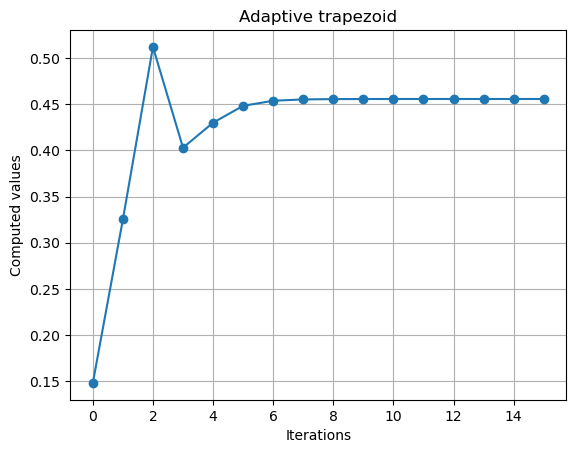

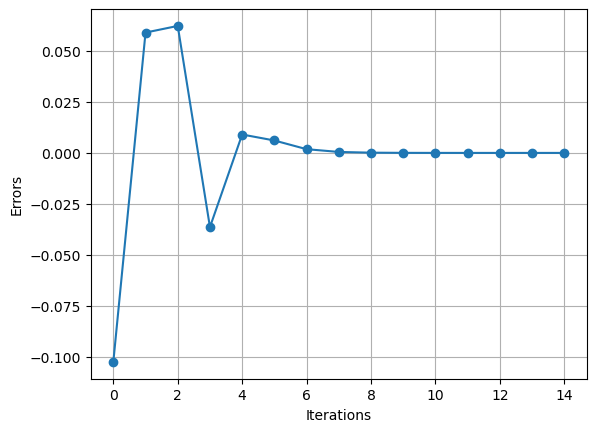

Error of final step=2.9626982515444194e-08


In [3]:
# 1.a Adaptive trapezoid
values = np.zeros(16, dtype=float)
N = 1

for i in range(16):
    I = Trapez(f, N, 0, 1) # Trapezoid method
    values[i] = I
    print(i, I)
    N *= 2

e_1a = np.zeros((len(values)-1), dtype=float) # Errors for 1.a

for i in range(len(values)-1):
    e_1a[i] = (values[i] - values[i-1])/3

plt.plot(values, '-o')
plt.title('Adaptive trapezoid')
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.grid()
plt.show()

plt.plot(e_1a, '-o')
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()
print(f"Error of final step={e_1a[-1]}")

0 0.147979484546652
1 0.38431604889308213
2 0.5873209727713417
3 0.34897386185747603
4 0.44580376471083255
5 0.455777492231097
6 0.4558324944613787
7 0.45583253230501364
8 0.45583253230908505
9 0.45583253230908505
10 0.45583253230908505
11 0.45583253230908516
12 0.4558325323090851
13 0.4558325323090852
14 0.4558325323090851
15 0.45583253230908516


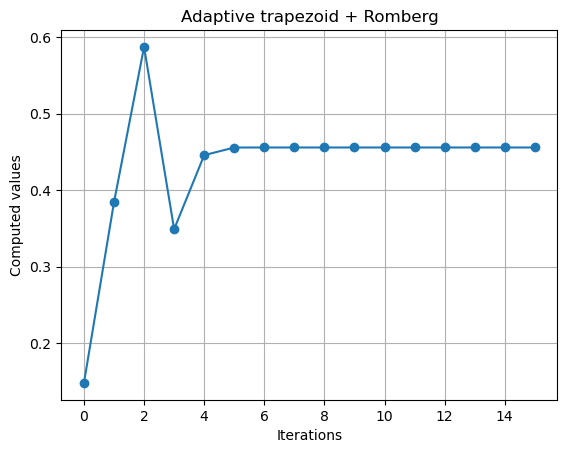

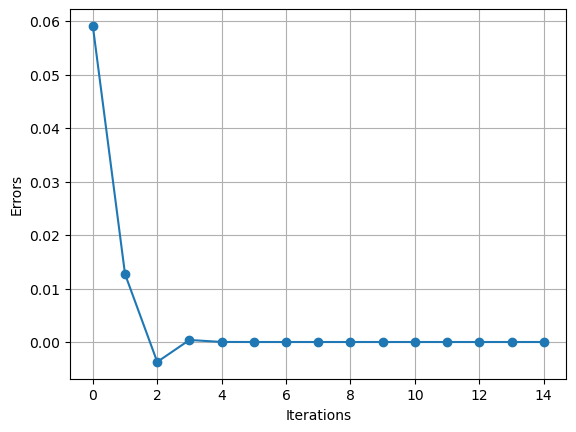

Error of final step=5.169878833271248e-26


In [4]:
# 1.b, Romberg + Adaptive trapezoid

N = 1
values = np.zeros((16), dtype=float)
e_1b = np.zeros((len(values)-1), dtype=float) # Errors for 1.b

for i in range(16):
    R_now = np.zeros((i + 1), dtype=float) # array for R_{i, m}
    R_now[0] = Trapez(f, N, 0, 1) # Trapezoid method

    for j in range(1, i+1):
        R_now[j] = R_now[j-1] + 1/(4**j - 1)*(R_now[j-1] - R_prev[j-1])
        
    if (i >= 1):
        e_1b[i-1] = (R_now[-2] - R_prev[-1])/(4**i - 1)
  
    print(i, R_now[-1])
    values[i] = R_now[-1]
    R_prev = np.copy(R_now) # array for R_{i-1, m}
    N *= 2

plt.plot(values, '-o')
plt.title('Adaptive trapezoid + Romberg')
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.grid()
plt.show()

plt.plot(e_1b, '-o')
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()
print(f"Error of final step={e_1b[-1]}")

# 1.c, Error comparison of 1.a and 1.b

Error of trapezoid method: $\epsilon_i=\dfrac{1}{3}(I_i-I_{i-1})$

Error of Romberg method: $c_mh_i^{2m}=\dfrac{1}{4^m-1}(R_{i,m} - R_{i-1,m})$

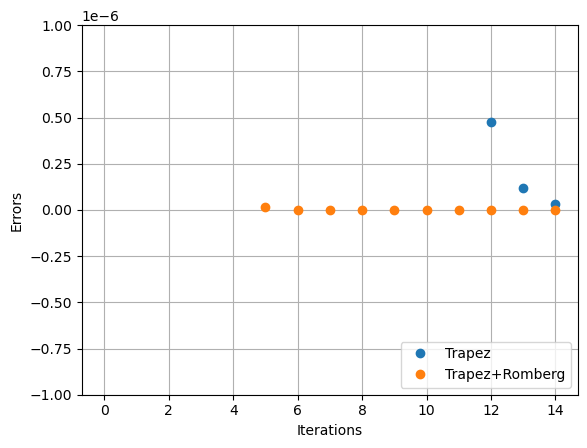

In [5]:
plt.plot(e_1a, 'o', label='Trapez')
plt.plot(e_1b, 'o', label='Trapez+Romberg')
plt.legend()
plt.ylim((-1E-6, 1E-6))
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()


From the above result, we can find Trapezoid + Romberg method reaches to the condition faster.

0 0.38431604889308213
1 0.5746331650289503
2 0.3665689810632206
3 0.4391386762335799
4 0.45451843128504427
5 0.45574568635801116
6 0.455827028758611
7 0.45583218714672064
8 0.4558325107178051
9 0.4558325309593389
10 0.4558325322247215
11 0.4558325323038124
12 0.4558325323087556
13 0.45583253230906456
14 0.45583253230908377
15 0.45583253230908505


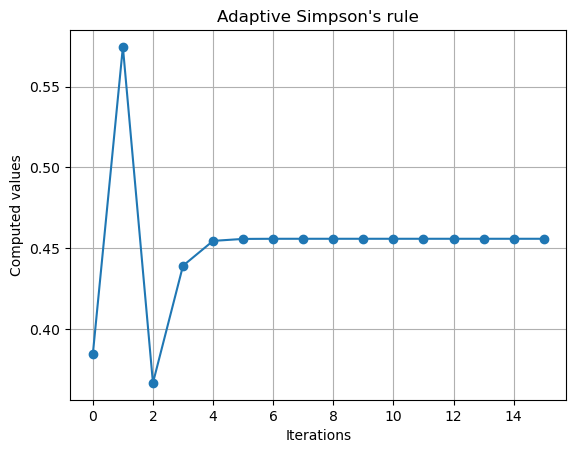

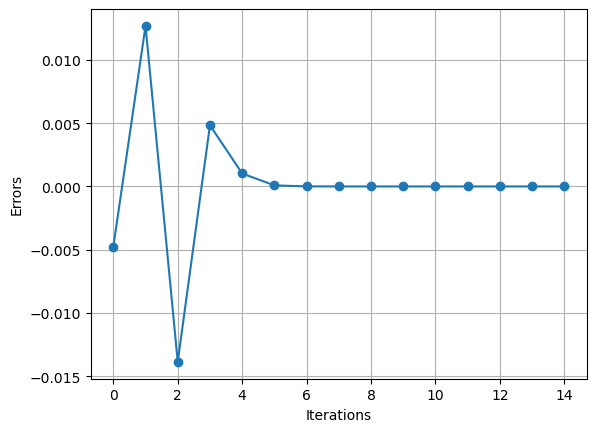

Error of final step=1.2804572217343472e-15


In [6]:
# 1.d Adaptive Simpson's rule
values = np.zeros(16, dtype=float)
N = 2

for i in range(16):
    I = Simpson(f, N, 0, 1) # Simpson's rule
    values[i] = I
    print(i, I)
    N *= 2

e_1d = np.zeros((len(values)-1), dtype=float) # Errors for 1.c

for i in range(len(values)-1):
    e_1d[i] = (values[i] - values[i-1])/15

plt.plot(values, '-o')
plt.title("Adaptive Simpson's rule")
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.grid()
plt.show()

plt.plot(e_1d, '-o')
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()
print(f"Error of final step={e_1d[-1]}")

0 0.38431604889308213
1 0.6380722037409065
2 0.2744903896968932
3 0.4775760765845903
4 0.4590890814468097
5 0.4558508106337675
6 0.455832544916479
7 0.45583253231044196
8 0.4558325323090852
9 0.45583253230908516
10 0.4558325323090852
11 0.4558325323090852
12 0.45583253230908516
13 0.45583253230908516
14 0.455832532309085
15 0.45583253230908516


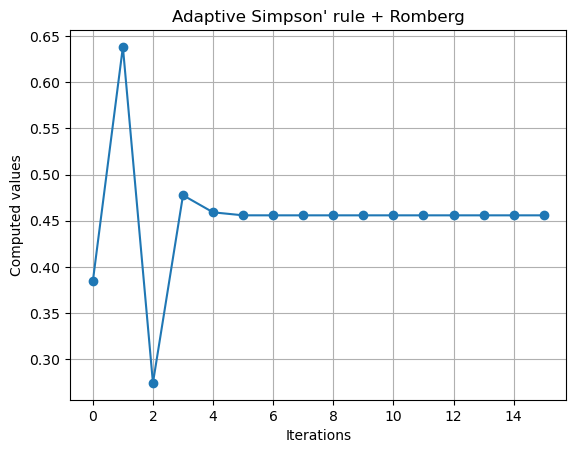

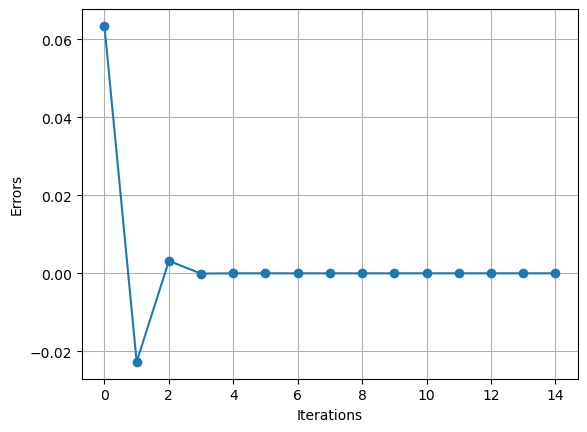

Error of final step=1.5509636499813743e-25


In [7]:
# 1.e Adaptive Simpson's rule + Romberg

N = 2
values = np.zeros((16), dtype=float)
e_1e = np.zeros((len(values)-1), dtype=float) # Errors for 1.b

for i in range(16):
    R_now = np.zeros((i + 1), dtype=float) # array for R_{i, m}
    R_now[0] = Simpson(f, N, 0, 1) # Simpson's rule

    for j in range(1, i+1):
        R_now[j] = R_now[j-1] + 1/(4**j - 1)*(R_now[j-1] - R_prev[j-1])
        
    if (i >= 1):
        e_1e[i-1] = (R_now[-2] - R_prev[-1])/(4**i - 1)
  
    print(i, R_now[-1])
    values[i] = R_now[-1]
    R_prev = np.copy(R_now) # array for R_{i-1, m}
    N *= 2

plt.plot(values, '-o')
plt.title("Adaptive Simpson' rule + Romberg")
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.grid()
plt.show()

plt.plot(e_1e, '-o')
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()
print(f"Error of final step={e_1e[-1]}")

# 1.f, Error comparison of 1.d and 1.e

Error of Simpson's rule: $\epsilon_i=\dfrac{1}{15}(I_i-I_{i-1})$

Error of Romberg method: $c_mh_i^{2m}=\dfrac{1}{4^m-1}(R_{i,m} - R_{i-1,m})$

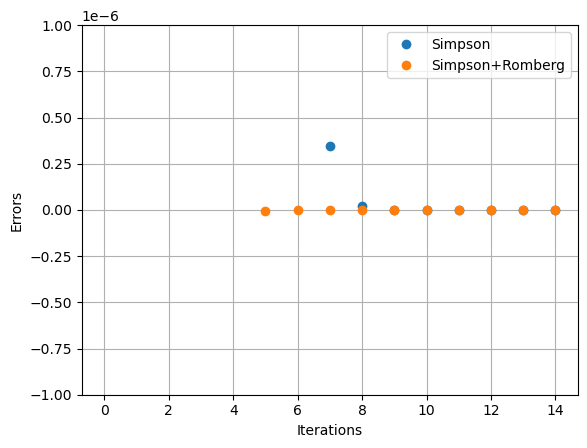

In [8]:
plt.plot(e_1d, 'o', label='Simpson')
plt.plot(e_1e, 'o', label='Simpson+Romberg')
plt.legend()
plt.ylim((-1E-6, 1E-6))
plt.xlabel('Iterations')
plt.ylabel('Errors')
plt.grid()
plt.show()


From the above result, we can find Simpson's rule + Romberg method reaches to the condition faster.

# Problem 2
### 2.a
<img src="data/2_2_a.png" width="600">


In [9]:
# 2.b 
# I used Simpson's rule to evaluate the integral. This method uses quadratic curve to approximate the integrand.

def f(z):
    # integrand
    x = z/(1-z)
    return x**3/(np.exp(x) - 1)/(1 - z)**2


values = np.zeros(16, dtype=float)
N = 2

for i in range(16):
    I = Simpson(f, N, 0.01, 0.99)
    values[i] = I
    print(i, I)
    N *= 2

print(f"Final result={I}")

0 1.520916044886804
1 7.568086121377486
2 7.077589204505114
3 6.382659552067448
4 6.4961420455351755
5 6.4939975016871605
6 6.4939391039883745
7 6.493939060002588
8 6.493939060027927
9 6.493939060029529
10 6.4939390600296285
11 6.493939060029635
12 6.493939060029636
13 6.493939060029635
14 6.493939060029636
15 6.493939060029636
Final result=6.493939060029636


Exact value=6.493939402266828
Error=5.270101415543027e-06%


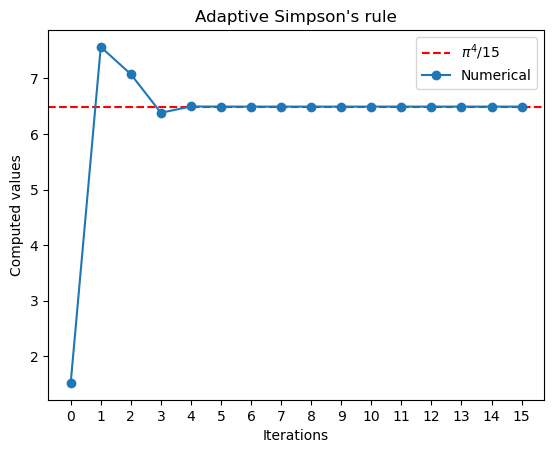

In [10]:
# 2.c

s = np.pi**4/15
print(f"Exact value={s}")
print(f"Error={np.abs(I - s)/s*100}%")

plt.axhline(y=s, color='r', linestyle='--', label='$\pi^4/15$')
plt.plot(values, '-o', label='Numerical')
plt.xticks(range(16))
plt.title("Adaptive Simpson's rule")
plt.xlabel('Iterations')
plt.ylabel('Computed values')
plt.legend()
plt.show()

In [11]:
# Or we can calcualte Stefan-Boltzmann constant directly,
import scipy.constants as sc

sigma = 5.670E-8 # W*m^-1*K^-4, known value of Stefan-Boltzmann constant
sigma_numerical = sc.k**4*I/(4*(np.pi**2)*(sc.c**2)*(sc.hbar)**3) # W*m^-1*K^-4, calculated Stefan-Boltzmann constant
error = np.abs(sigma - sigma_numerical)/sigma*100
print(f"Known value = {sigma}")
print(f"Calculated value = {sigma_numerical}")
print(f"Error = {error}%")

Known value = 5.67e-08
Calculated value = 5.6703741203499457e-08
Error = 0.006598242503454165%


# Problem 3

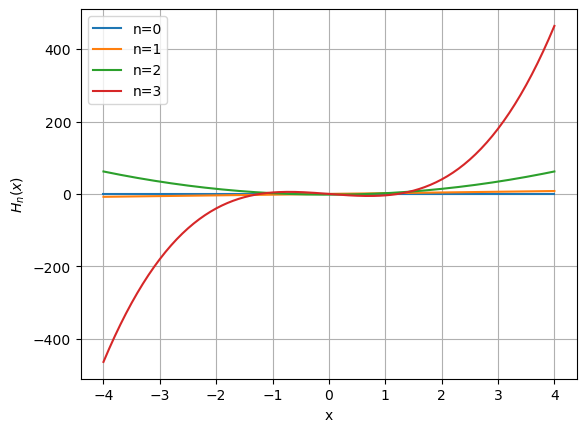

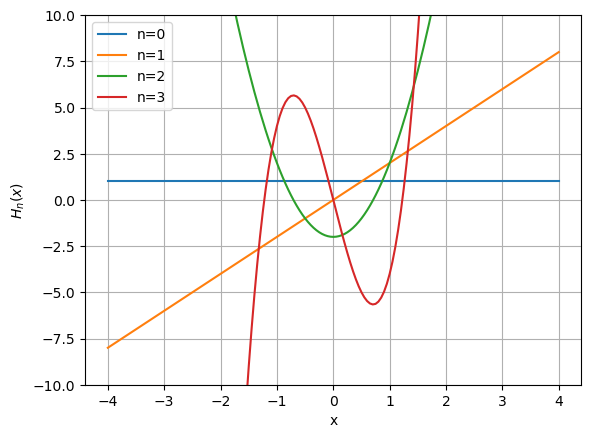

In [12]:
# 3.a

def H(n, x):
    # Hermite polynomial, H_n(x)
    H0 = np.ones_like(x)
    H1 = 2*x

    if n == 0: return H0
    elif n == 1: return H1
    else:
        for k in range(1, n): 
            # k = n -1
            H2 = 2*x*H1 - 2*k*H0
            H0, H1 = H1, H2

        return H1 # H2 is already sotred in H1


h = 0.05
x = np.arange(-4, 4 + h, h)

y0 = H(0, x)
y1 = H(1, x)
y2 = H(2, x)
y3 = H(3, x)


plt.plot(x, y0, label="n=0")
plt.plot(x, y1, label="n=1")
plt.plot(x, y2, label="n=2")
plt.plot(x, y3, label="n=3")
plt.xlabel('x')
plt.ylabel('$H_n(x)$')
plt.legend()
plt.grid()

plt.show()

plt.plot(x, y0, label="n=0")
plt.plot(x, y1, label="n=1")
plt.plot(x, y2, label="n=2")
plt.plot(x, y3, label="n=3")
plt.xlabel('x')
plt.ylabel('$H_n(x)$')
plt.ylim((-10, 10))
plt.legend()
plt.grid()

plt.show()

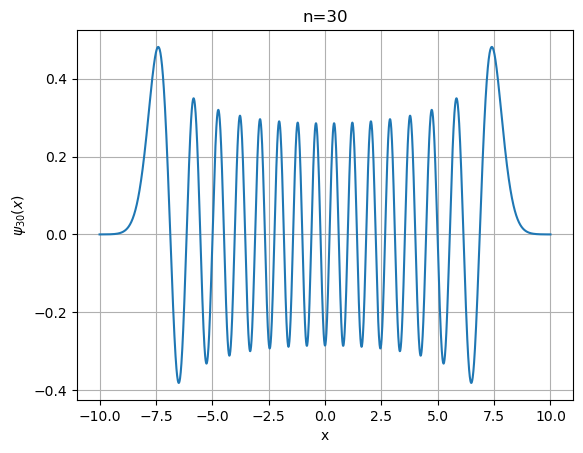

norm=0.9999999999262221


In [13]:
# 3.b

def factorial(n):
    # n!
    f0 = 1

    if n == 0: return f0
    else:
        for k in range(1, n+1):
            f1 = k*f0
            f0 = f1

        return f0 # f2 is already sotred in f1
    

def psi(n, x):
    # Psi_n(x)
    return 1/np.sqrt(2**n*factorial(n)*np.sqrt(np.pi))*np.exp(-x*x/2)*H(n, x)

h = 0.01
x = np.arange(-10, 10 + h, h)

psi30 = psi(30, x)
norm = Simpson(lambda x:psi(30, x)*psi(30, x), 1000, -10, 10) # norm=1

plt.plot(x, psi30, label="n=30")
plt.xlabel('x')
plt.ylabel('$\\psi_{30}(x)$')
plt.title('n=30')
plt.grid()
plt.show()
print(f"norm={norm}")

In [14]:
def Gauss_quad(f, n, a, b):
    # Gaussain quadrature integrates over [a, b]
    # f: integrand
    # n: degree
    x_i = np.polynomial.legendre.legroots(np.polynomial.legendre.Legendre.basis(n).coef) # roots of P_n(x)
    P_n = np.polynomial.legendre.Legendre.basis(n) # P_n(x) polynomial
    dP_ndx = P_n.deriv()(x_i) # dP_n/dx|x=x_i

    w = (2/(1 - x_i*x_i)/dP_ndx**2)*(b - a)/2
    I = np.sum(w*f(x_i*(b - a)/2 + (b + a)/2))
    
    return I


# For the test of Gaussian quadrature method
I1 = Gauss_quad(lambda x:x**4 - 2*x + 1, 3, 0, 2) # I1 = 4.4
print(I1)
I2 = Gauss_quad(lambda x:psi(30, x)*psi(30, x), 100, -10, 10) # I2 = 1
print(I2)

# Uncertainty
n = 5
X2 = Gauss_quad(lambda x:x*x*psi(n, x)*psi(n, x), 100, -10, 10)
print(f"\nUncertainty for n={n} is ...")
print(f"sqrt(<x^2>)={np.sqrt(X2)}")

4.399999999999999
0.9999999227013247

Uncertainty for n=5 is ...
sqrt(<x^2>)=2.345207879911721


# Problem 4
Data: https://public.websites.umich.edu/~mejn/cp/programs.html

In [15]:
def df(w, hx, hy):
    # Central difference, 1st order
    dwdx = (w[:, 2:] - w[:, :-2])/(2*hx)
    dwdy = (w[2:, :] - w[:-2, :])/(2*hy)
    return dwdx, dwdy


def I(phi, dwdx, dwdy):
    intensity = -(np.cos(phi)*dwdx[1:-1,:] + np.sin(phi)*dwdy[:, 1:-1])/np.sqrt(dwdx[1:-1,:]**2+ dwdy[:, 1:-1]**2 + 1)

    return intensity


def dataload(filename):
    with open(filename, "r") as file:
        lines = file.readlines()

    Ny = len(lines)
    Nx = len([float(x) for x in lines[0].strip().split(' ')])

    w = np.zeros((Ny, Nx), dtype=float)

    for i, line in enumerate(lines):
        x = [float(x) for x in line.strip().split(' ')]
        w[i] = x

    return w


def imPlot(img, title, color_map='viridis'):
    ax = plt.gca() 
    im = ax.imshow(img, cmap=color_map)
    ax.set_title(title)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.1)
    plt.colorbar(im, cax=cax)
    plt.show()


def plot_3d(img, title):
    fig = plt.figure()
    ax = plt.axes(projection='3d')
    x = np.arange(img.shape[1])
    y = np.arange(img.shape[0])
    X, Y= np.meshgrid(x, y)
    surf = ax.plot_surface(X, Y, img, cmap='jet')

    plt.title(title)
    fig.colorbar(surf, shrink=1.0, aspect=20)
    ax.view_init(elev=75, azim=45)

    plt.show()

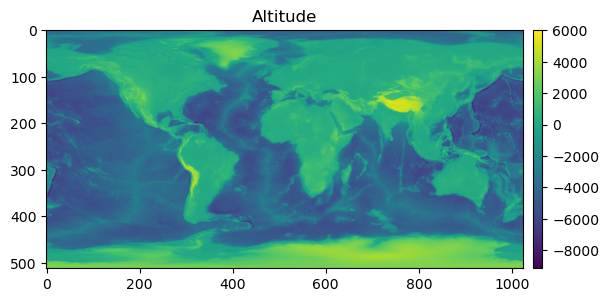

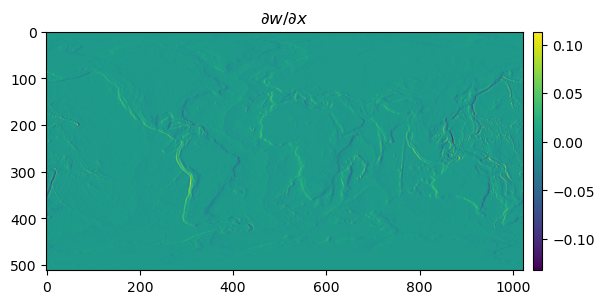

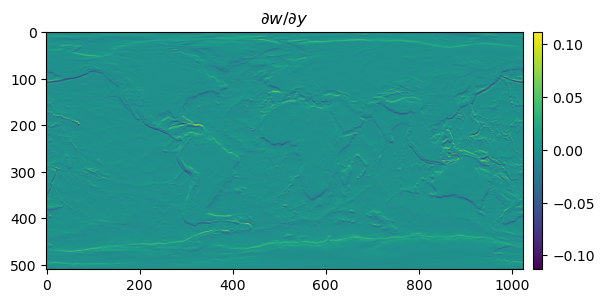

In [16]:
# 4.a, Surface of the earth
w = dataload("data/altitude.txt") # This file contains the altitude w(x,y) in meters above sea level of the surface of the earth.
dwdx, dwdy = df(w, 30000, 30000) 

imPlot(w, "Altitude")
imPlot(dwdx,"$\\partial w/\\partial x$")
imPlot(dwdy, "$\\partial w/\\partial y$")

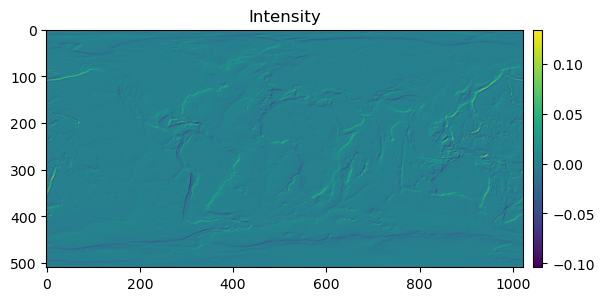

Maximum intensity=0.13458438112365592
Minimum intensity=-0.10398009450777584


In [17]:
# 4.b
I_earth = I(np.pi/4, dwdx, dwdy)
imPlot(I_earth, "Intensity")

print(f"Maximum intensity={np.max(I_earth)}")
print(f"Minimum intensity={np.min(I_earth)}")

We can see that $I$ has negative values at some points. These regions corresponds to shadows. Since $I=|{\bf a}|\cos\theta$, $I$ become negative when $\theta>90\degree$, which means that the incident light enters from behind the wall and casts a shadow in that region. By setting cut off $I>0$, we obtain below figure.

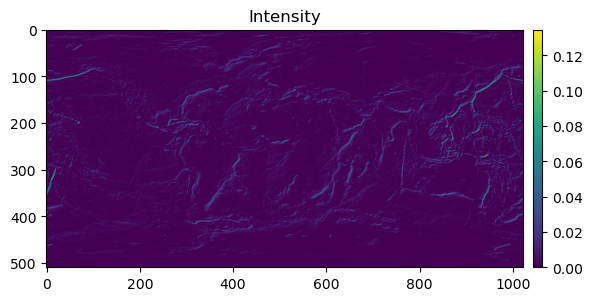

Maximum intensity=0.13458438112365592
Minimum intensity=0.0


In [18]:
I_earth = np.maximum(0, I(np.pi/4, dwdx, dwdy))
imPlot(I_earth, "Intensity")

print(f"Maximum intensity={np.max(I_earth)}")
print(f"Minimum intensity={np.min(I_earth)}")

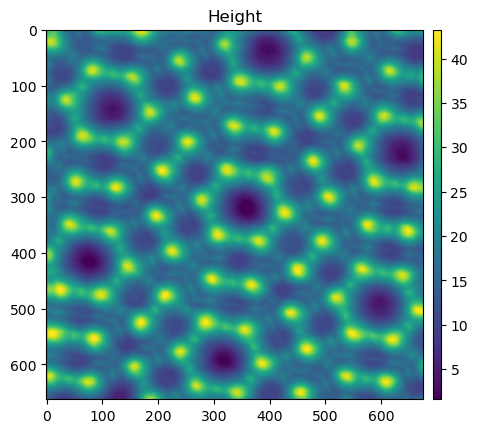

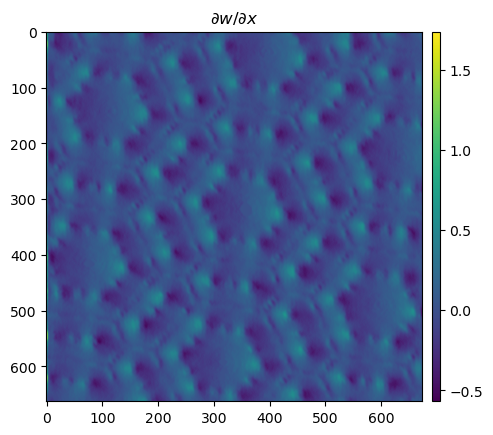

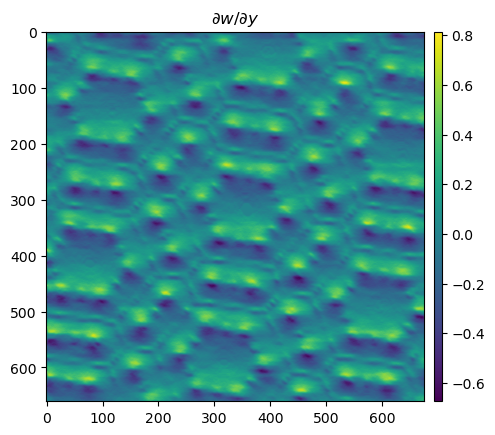

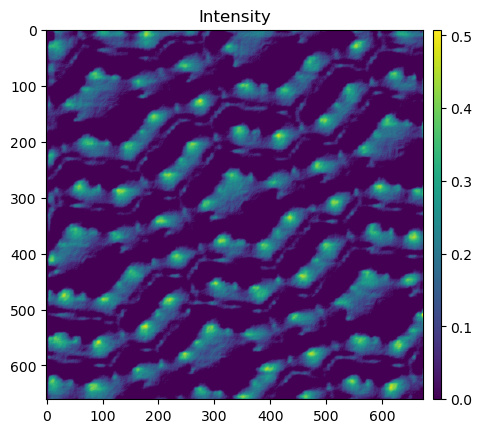

Maximum intensity=0.5077886627905275
Minimum intensity=0.0


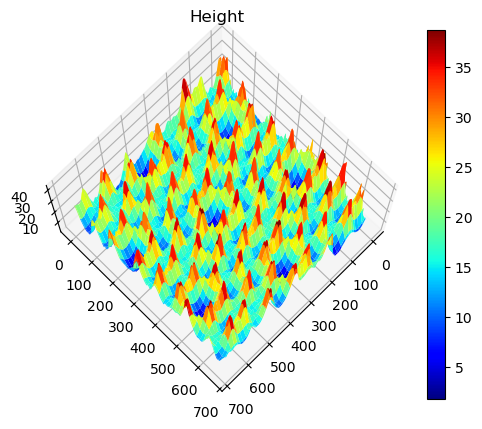

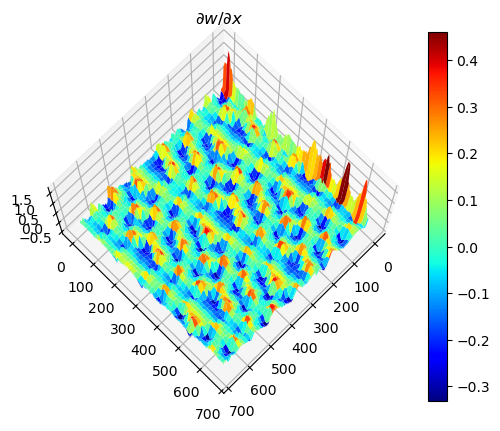

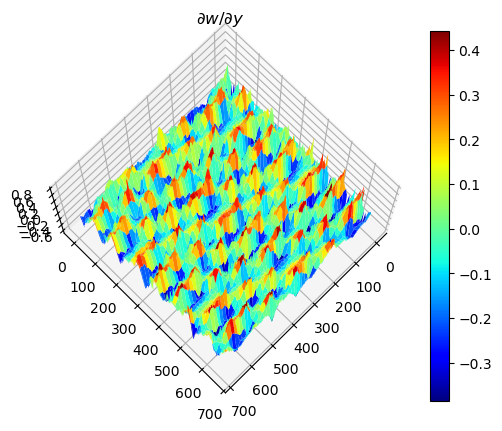

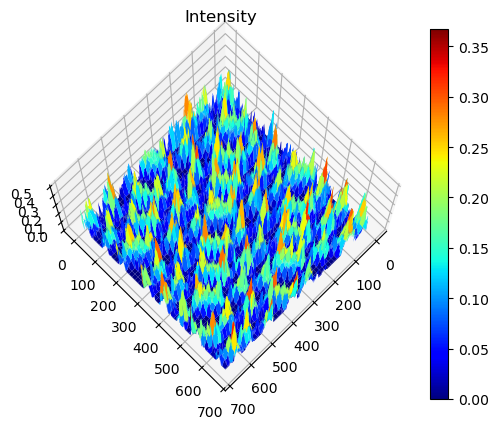

In [19]:
# 4.c, STM
w = dataload("data/stm.txt") # This file contains the STM image of the (111) surface of silicon.
dwdx, dwdy = df(w, 2.5, 2.5)
I_STM = np.maximum(0, I(np.pi/4, dwdx, dwdy))

# 2d plots
imPlot(w, "Height")
imPlot(dwdx,"$\\partial w/\\partial x$")
imPlot(dwdy, "$\\partial w/\\partial y$")
imPlot(I_STM, "Intensity")
print(f"Maximum intensity={np.max(I_STM)}")
print(f"Minimum intensity={np.min(I_STM)}")

# 3d plots
plot_3d(w, "Height")
plot_3d(dwdx,"$\\partial w/\\partial x$")
plot_3d(dwdy, "$\\partial w/\\partial y$")
plot_3d(I_STM, "Intensity")